In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision.ops import box_iou, generalized_box_iou_loss
from ultralytics import YOLO
import ultralytics

In [2]:
# Matching at evaluation IoU = 0.50, 1 = TP, 0 = FP
scores = np.array([0.95, 0.90, 0.80, 0.70, 0.40, 0.20])
tp_flags = np.array([1, 0, 1, 1, 0, 0])
num_gt = 4

for threshold in [0.85, 0.65, 0.25, 0.10]:
    keep = scores >= threshold
    
    tp = int(tp_flags[keep].sum())
    fp = int(keep.sum()) - tp
    fn = num_gt - tp
    
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / num_gt
    f1 = 2 * tp / (2 * tp + fp + fn)
    
    print(
        f"conf={threshold:.2f} | TP={tp} FP={fp} FN={fn} | "
        f"P={precision:.4f} R={recall:.4f} F1={f1:.4f}"
    )

conf=0.85 | TP=1 FP=1 FN=3 | P=0.5000 R=0.2500 F1=0.3333
conf=0.65 | TP=3 FP=1 FN=1 | P=0.7500 R=0.7500 F1=0.7500
conf=0.25 | TP=3 FP=2 FN=1 | P=0.6000 R=0.7500 F1=0.6667
conf=0.10 | TP=3 FP=3 FN=1 | P=0.5000 R=0.7500 F1=0.6000


**Cumulative Precision–Recall**

In [3]:
def precision_recall_curve(scores, tp_flags, num_gt):
    order = np.argsort(-np.asarray(scores), kind="stable")
    flags = np.asarray(tp_flags)[order]
    
    cumulative_tp = np.cumsum(flags)
    cumulative_fp = np.cumsum(1 - flags)
    
    precision = cumulative_tp / (cumulative_tp + cumulative_fp)
    recall = cumulative_tp / num_gt
    
    return precision, recall

precision, recall = precision_recall_curve(
    scores, tp_flags, num_gt
)

print("Precision:", np.round(precision, 4))
print("Recall   :", np.round(recall, 4))

Precision: [          1         0.5      0.6667        0.75         0.6         0.5]
Recall   : [       0.25        0.25         0.5        0.75        0.75        0.75]


**Calculate AP**

In [4]:
def ap101(precision, recall):
    recall_levels = np.linspace(0, 1, 101)
    
    interpolated = np.array([
        max(precision[recall >= level], default=0.0)
        for level in recall_levels
    ])
    
    return float(interpolated.mean()), recall_levels, interpolated

ap, recall_levels, interpolated = ap101(precision, recall)
print(f"AP@0.50: {ap:.4f}")

AP@0.50: 0.6287


**Show PR curve and interpolation**

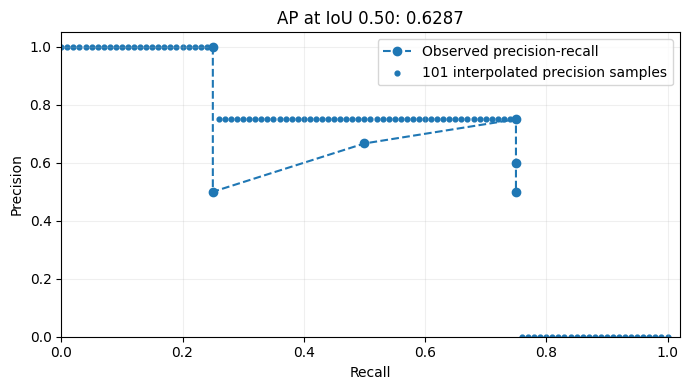

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(recall, precision, "o--", label="Observed precision-recall")
ax.scatter(recall_levels, interpolated, s=12, label="101 interpolated precision samples")

ax.set(
    xlim=(0, 1.02),
    ylim=(0, 1.05),
    xlabel="Recall",
    ylabel="Precision",
    title=f"AP at IoU 0.50: {ap:.4f}",
)

ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

**Ranking experiment**

In [6]:
rankings = {
    "Better ranking": np.array([1, 1, 1, 0, 0, 0]),
    "Worse ranking":  np.array([0, 0, 0, 1, 1, 1]),
}

for name, flags in rankings.items():
    p, r = precision_recall_curve(scores, flags, num_gt)
    ranking_ap, _, _ = ap101(p, r)
    
    print(
        f"{name}: P={p[-1]:.4f}, R={r[-1]:.4f}, "
        f"AP={ranking_ap:.4f}"
    )

Better ranking: P=0.5000, R=0.7500, AP=0.7525
Worse ranking: P=0.5000, R=0.7500, AP=0.3762


**AP to mAP**

In [7]:
iou_thresholds = np.linspace(0.50, 0.95, 10)

ap_matrix = np.array([
    [0.90, 0.88, 0.84, 0.80, 0.76, 0.70, 0.62, 0.50, 0.32, 0.12],
    [0.60, 0.58, 0.55, 0.50, 0.45, 0.40, 0.32, 0.24, 0.14, 0.05],
])

print(f"mAP50   : {ap_matrix[:, 0].mean():.4f}")
print(f"mAP75   : {ap_matrix[:, 5].mean():.4f}")
print(f"mAP50-95: {ap_matrix.mean():.4f}")

mAP50   : 0.7500
mAP75   : 0.5500
mAP50-95: 0.5135


**BCE and gradient**

In [8]:
logits = torch.tensor([2.0, -2.0], requires_grad=True)
targets = torch.tensor([1.0, 1.0])

losses = F.binary_cross_entropy_with_logits(
    logits,
    targets,
    reduction="none",
)

print("Per-example loss:", losses.detach())
losses.mean().backward()
print("Gradient:", logits.grad)

Per-example loss: tensor([0.1269, 2.1269])
Gradient: tensor([-0.0596, -0.4404])


In [9]:
target_boxes = torch.tensor([
    [0, 0, 100, 100],
    [0, 0, 100, 100],
], dtype=torch.float32)

pred_boxes = torch.tensor([
    [200, 0, 300, 100],
    [120, 0, 220, 100], 
], dtype=torch.float32)

iou_losses = 1 - box_iou(pred_boxes, target_boxes).diag()

giou_losses = generalized_box_iou_loss(
    pred_boxes, target_boxes,
    reduction="none"
)

print("IoU losses :", iou_losses)
print("GIoU losses:", giou_losses)

IoU losses : tensor([1., 1.])
GIoU losses: tensor([1.3333, 1.0909])
